In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Convert to DataFrame for easier handling
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

# Check for missing values
print(df.isnull().sum())

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

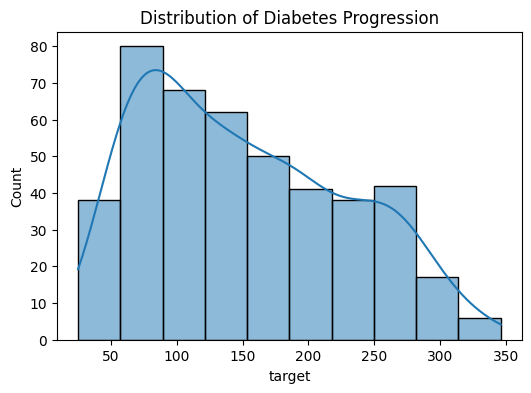

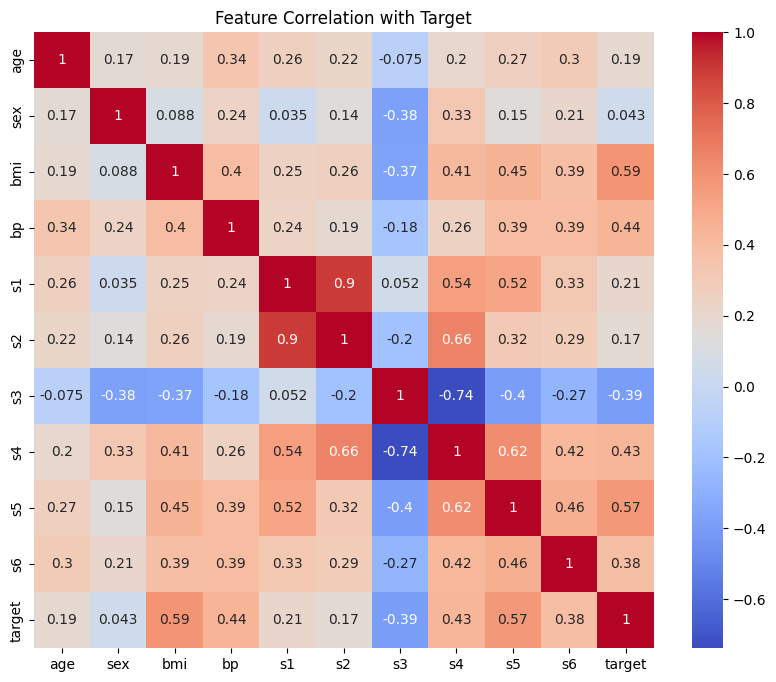

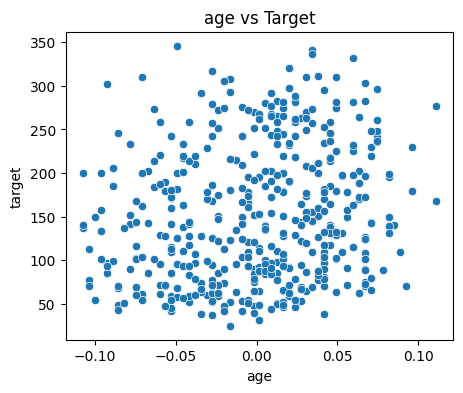

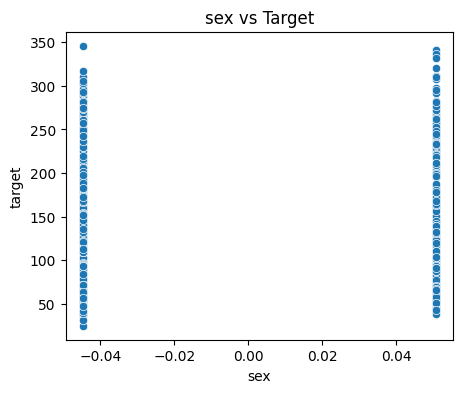

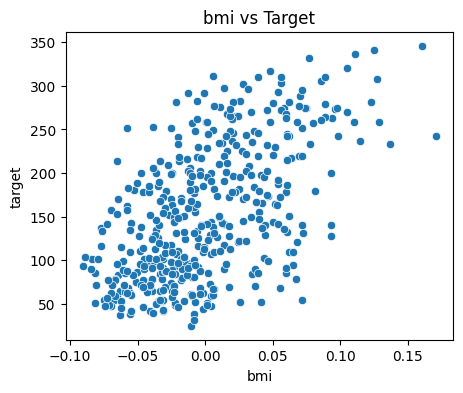

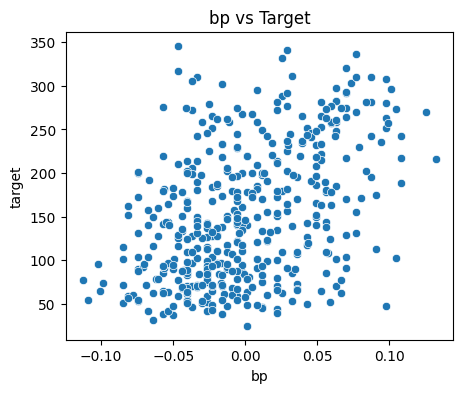

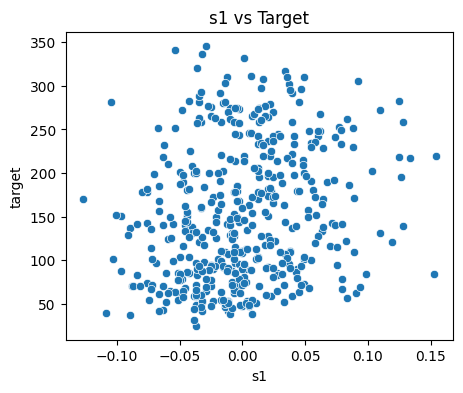

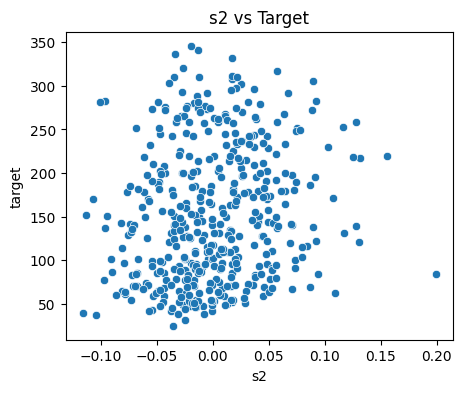

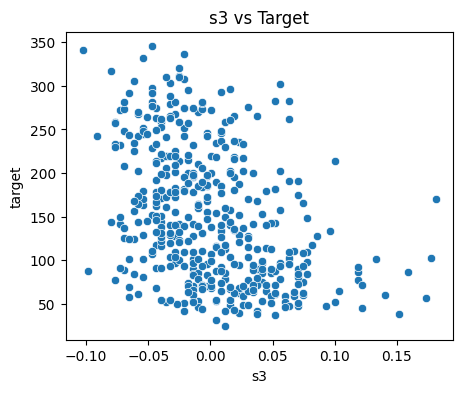

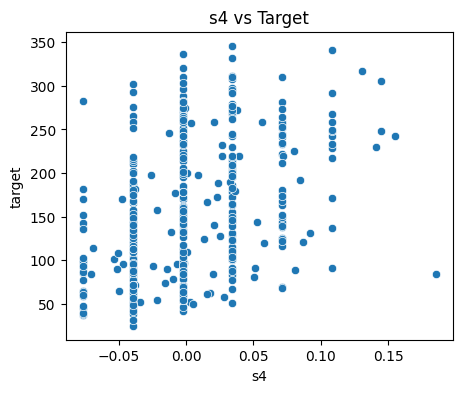

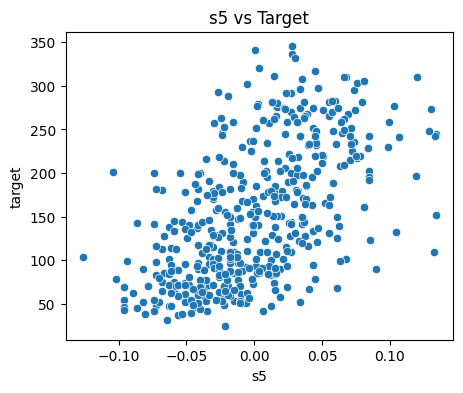

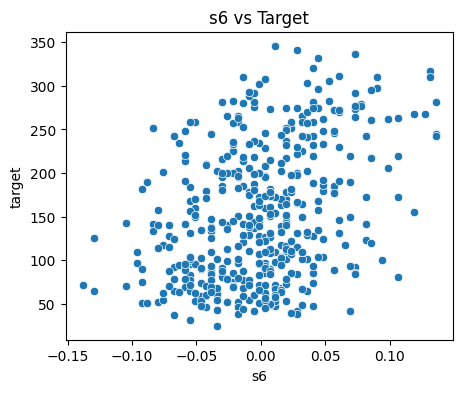

In [ ]:
# Basic statistics
print(df.describe())

# Distribution of target variable
plt.figure(figsize=(6,4))
sns.histplot(df['target'], kde=True)
plt.title("Distribution of Diabetes Progression")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Target")
plt.show()

# Scatter plots for feature vs target
for col in diabetes.feature_names:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[col], y=df['target'])
    plt.title(f"{col} vs Target")
    plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build ANN
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 31357.8223 - mae: 158.1471 - val_loss: 22197.6777 - val_mae: 133.0515
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30984.3438 - mae: 157.0099 - val_loss: 21855.8281 - val_mae: 131.8260
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30389.9922 - mae: 155.2854 - val_loss: 21309.5020 - val_mae: 129.8892
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29430.5918 - mae: 152.4222 - val_loss: 20449.0254 - val_mae: 126.8370
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27912.4766 - mae: 147.9643 - val_loss: 19190.3730 - val_mae: 122.3079
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25697.9785 - mae: 141.2122 - val_loss: 17446.3789 - val_mae: 115.8253
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22756.2773 - mae: 131.6829 - val_loss: 15214.0879 - val_mae: 106.9401
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19104.7148 - mae: 118.9263 - val_loss

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Mean Squared Error: 2850.469615354458
R2 Score: 0.4619879251000042


In [ ]:
# Experiment with deeper network
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

history2 = model2.fit(X_train, y_train, epochs=150, batch_size=16, validation_split=0.2, verbose=1)

# Evaluate again
y_pred2 = model2.predict(X_test)
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("Improved Model - MSE:", mse2)
print("Improved Model - R2 Score:", r2_2)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 31317.1738 - mae: 158.0014 - val_loss: 22040.8125 - val_mae: 132.4577
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30414.4902 - mae: 155.2169 - val_loss: 20826.5625 - val_mae: 127.9974
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27637.1172 - mae: 146.4451 - val_loss: 17353.1230 - val_mae: 114.7523
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20161.6953 - mae: 121.2419 - val_loss: 10141.5459 - val_mae: 81.1572
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9132.6514 - mae: 74.8822 - val_loss: 3785.2664 - val_mae: 44.7596
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5188.1650 - mae: 56.5867 - val_loss: 3275.4568 - val_mae: 44.6314
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4315.5112 - mae: 52.5820 - val_loss: 3127.8218 - val_mae: 42.0640
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3995.8586 - mae: 49.9941 - val_loss: 3054.3838 - val_mae: 41.